Подгружаем датасеты. Для сохранности данных в случае прерывания сессии colab, монтируем Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/Аналитика данных_ДЗ_Миннибаев Артур Маратович/Блок 2/'

dataset = pd.read_csv(path + 'newborns_stats.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Проведу EDA

In [ ]:
print(dataset.shape)
print(dataset.dtypes)
print(dataset.head(10))

(123, 5)
year        int64
month       int64
c1        float64
cat1        int64
target      int64
dtype: object
   year  month      c1  cat1  target
0  2015      1     NaN     0   12346
1  2015      2     NaN     0   11210
2  2015      3  40.045     0   12237
3  2015      4  39.860     0   12685
4  2015      5  42.367     1   12881
5  2015      6  43.462     1   13644
6  2015      7  45.092     1   14857
7  2015      8  48.452     1   13812
8  2015      9  48.737     1   13402
9  2015     10  46.264     2   13796


In [ ]:
print(dataset.isnull().sum())
print(dataset.describe())

year      0
month     0
c1        2
cat1      0
target    0
dtype: int64
              year       month          c1        cat1        target
count   123.000000  123.000000  121.000000  123.000000    123.000000
mean   2019.634146    6.390244   38.793198    0.731707  11361.325203
std       2.973292    3.496214    4.832976    0.725114   1527.817191
min    2015.000000    1.000000   29.034000    0.000000   6611.000000
25%    2017.000000    3.000000   34.979000    0.000000  10294.500000
50%    2020.000000    6.000000   38.235000    1.000000  11314.000000
75%    2022.000000    9.000000   42.459000    1.000000  12426.500000
max    2025.000000   12.000000   49.647000    2.000000  14857.000000


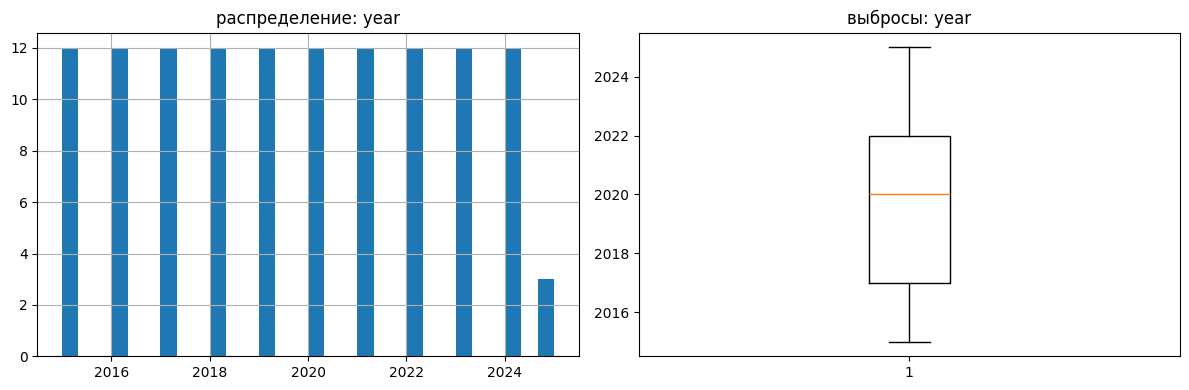

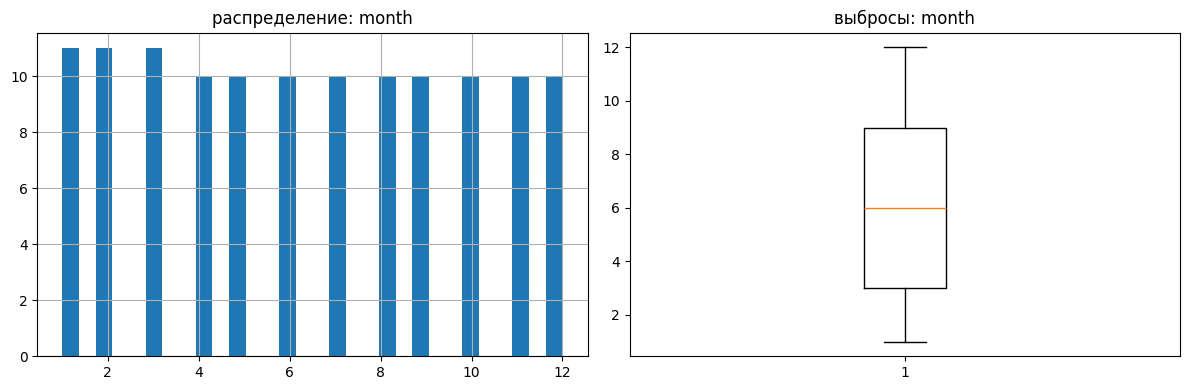

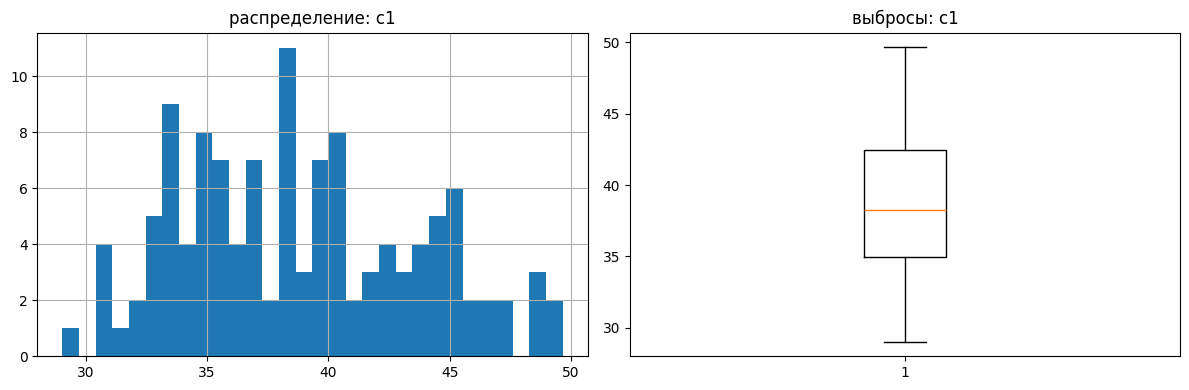

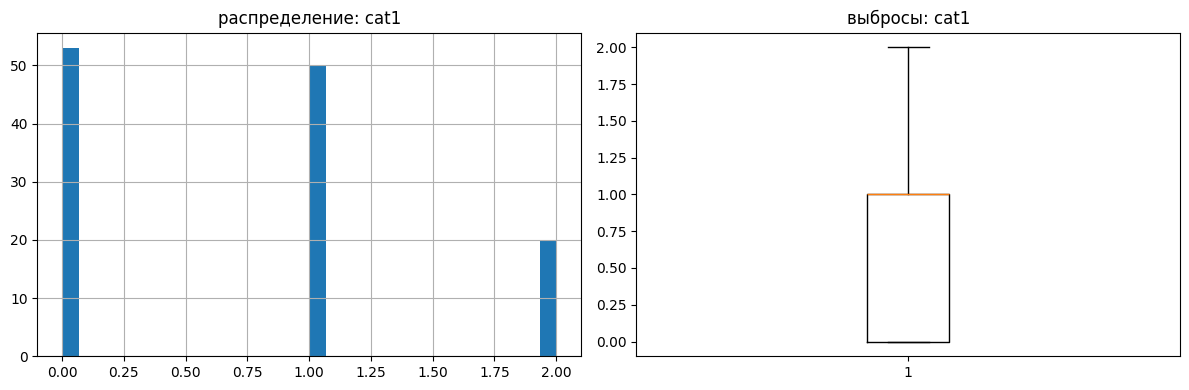

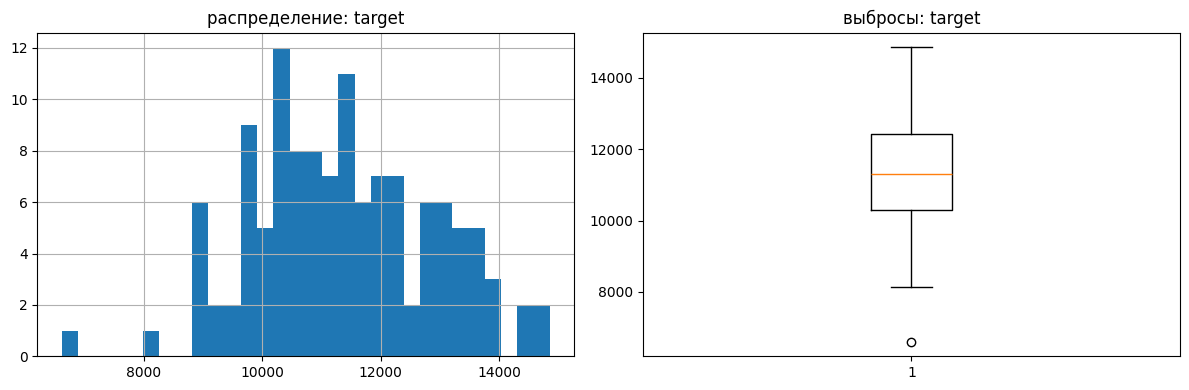

In [ ]:
import matplotlib.pyplot as plt

for col in dataset.select_dtypes(include='number').columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    dataset[col].hist(bins=30, ax=axes[0])
    axes[0].set_title(f'распределение: {col}')

    axes[1].boxplot(dataset[col].dropna())
    axes[1].set_title(f'выбросы: {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
print(dataset.shape)
print(dataset.tail(10))
print(f'\nвсего строк: {len(dataset)}')
print(f'период: {dataset["year"].min()}-{dataset["year"].max()}')

(123, 5)
     year  month      c1  cat1  target
113  2024      6  33.623     1   10398
114  2024      7  35.397     1   11413
115  2024      8  37.079     1   10995
116  2024      9  38.094     1    9947
117  2024     10  35.601     2   10629
118  2024     11  34.979     2    9751
119  2024     12  34.646     0    9225
120  2025      1  32.259     0    8927
121  2025      2  30.858     0    8152
122  2025      3  29.034     0    6611

всего строк: 123
период: 2015-2025


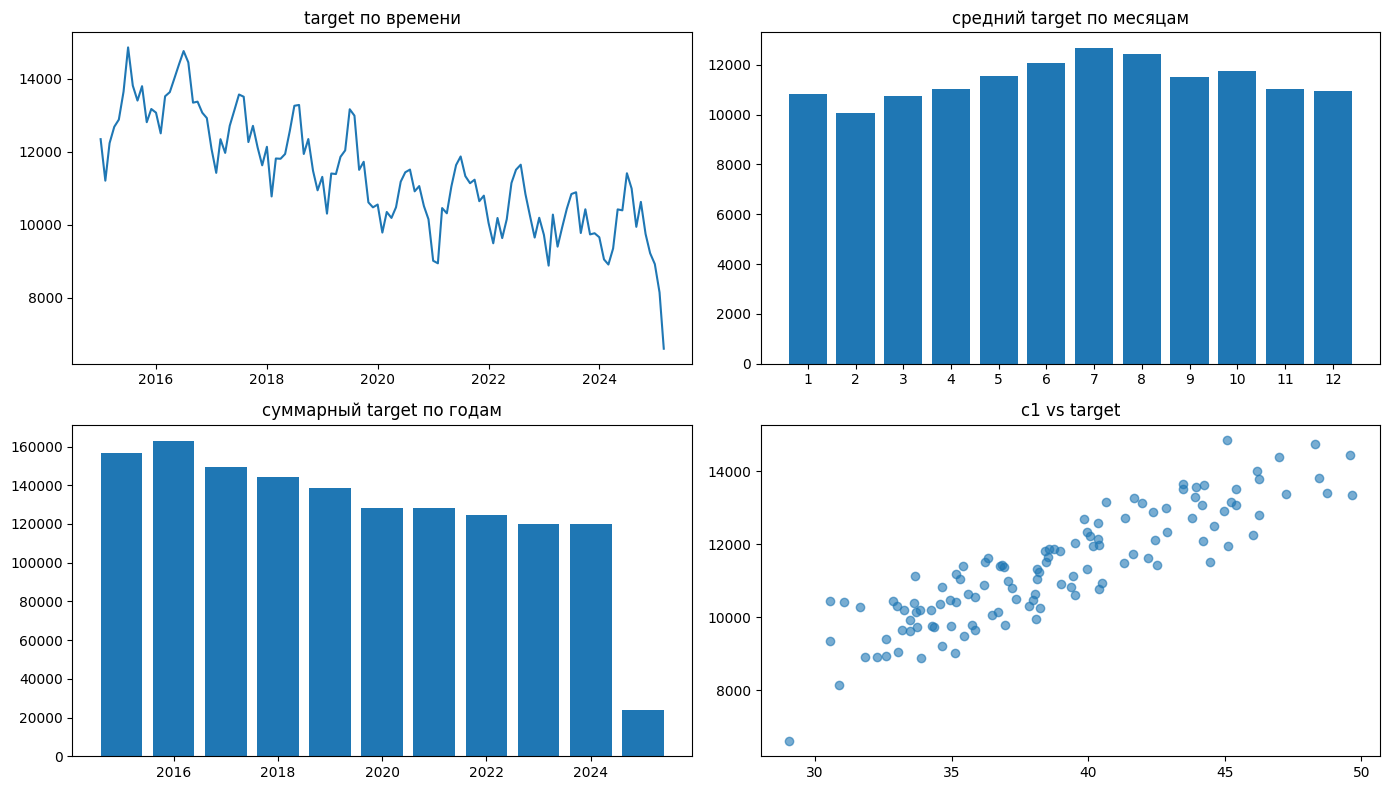

In [ ]:
# посмотрим на сезонность target по месяцам
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dataset['date'] = pd.to_datetime(dataset[['year', 'month']].assign(day=1))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# общий тренд
axes[0, 0].plot(dataset['date'], dataset['target'])
axes[0, 0].set_title('target по времени')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# сезонность по месяцам
monthly_avg = dataset.groupby('month')['target'].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values)
axes[0, 1].set_title('средний target по месяцам')
axes[0, 1].set_xticks(range(1, 13))

# target по годам
yearly_avg = dataset.groupby('year')['target'].sum()
axes[1, 0].bar(yearly_avg.index, yearly_avg.values)
axes[1, 0].set_title('суммарный target по годам')

# c1 vs target
axes[1, 1].scatter(dataset['c1'], dataset['target'], alpha=0.6)
axes[1, 1].set_title('c1 vs target')

plt.tight_layout()
plt.show()

In [ ]:
print(dataset.tail(5))

     year  month      c1  cat1  target       date
118  2024     11  34.979     2    9751 2024-11-01
119  2024     12  34.646     0    9225 2024-12-01
120  2025      1  32.259     0    8927 2025-01-01
121  2025      2  30.858     0    8152 2025-02-01
122  2025      3  29.034     0    6611 2025-03-01


In [ ]:
df['c1'] = df['c1'].interpolate(method='linear')

print(df[['date', 'target']].head(3))
print(df.isnull().sum())

        date  target
0 2015-01-01   12346
1 2015-02-01   11210
2 2015-03-01   12237
year      0
month     0
c1        2
cat1      0
target    0
date      0
dtype: int64


In [ ]:
df['c1'] = df['c1'].interpolate(method='linear').bfill()

print(df.isnull().sum())

year      0
month     0
c1        0
cat1      0
target    0
date      0
dtype: int64


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train = df.set_index('date')['target']

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit = model.fit()
print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                   target   No. Observations:                  123
Model:             ExponentialSmoothing   SSE                       18563474.497
Optimized:                         True   AIC                           1498.716
Trend:                         Additive   BIC                           1543.711
Seasonal:                      Additive   AICC                          1505.293
Seasonal Periods:                    12   Date:                 Wed, 17 Jun 2026
Box-Cox:                          False   Time:                         16:52:13
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.5281646                alpha                 True
smoothing_trend          

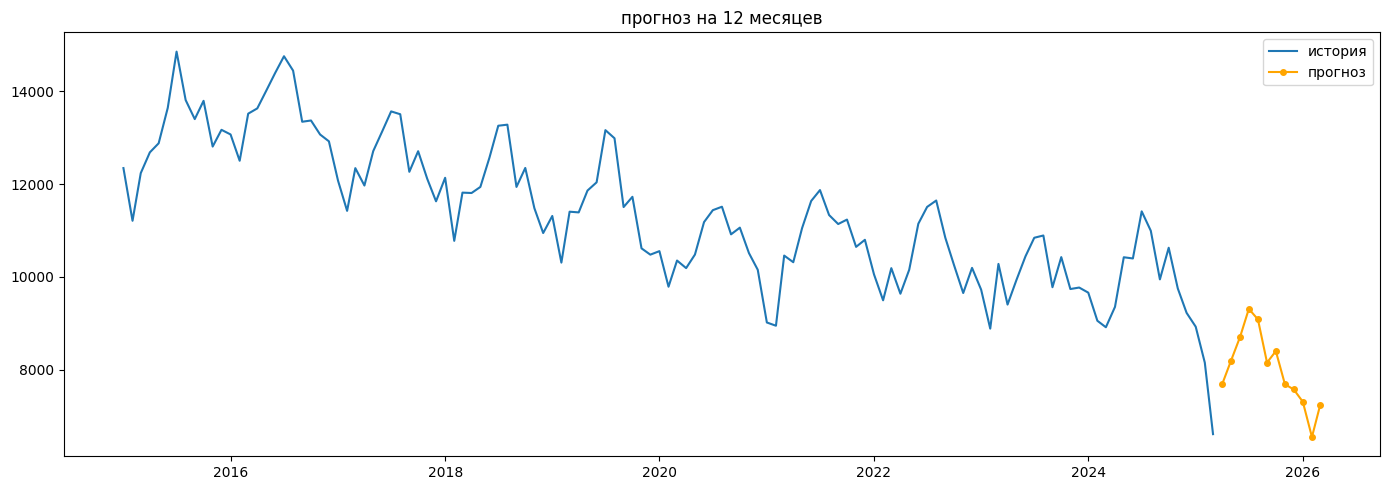

2025-04-01    7684
2025-05-01    8189
2025-06-01    8704
2025-07-01    9311
2025-08-01    9085
2025-09-01    8153
2025-10-01    8401
2025-11-01    7685
2025-12-01    7575
2026-01-01    7308
2026-02-01    6549
2026-03-01    7237
Freq: MS, dtype: int64


In [ ]:
forecast = fit.forecast(12)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='история')
plt.plot(forecast.index, forecast, label='прогноз', color='orange', marker='o', markersize=4)
plt.title('прогноз на 12 месяцев')
plt.legend()
plt.tight_layout()
plt.show()

print(forecast.round(0).astype(int))

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.9 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

sarima_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trend='t',
    stepwise=True,
    information_criterion='aic',
    trace=True
)

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1899.087, Time=3.82 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1943.130, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1880.611, Time=0.69 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1898.235, Time=0.81 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1943.130, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1940.661, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1881.859, Time=1.47 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1877.383, Time=1.19 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1897.796, Time=0.95 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=6.94 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=1873.047, Time=2.55 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1891.565, Time=0.88 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.00 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=1.44 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_no_drift = SARIMAX(
    train,
    order=(2, 1, 0),
    seasonal_order=(1, 0, 2, 12),
    trend='n'
)

fit_no_drift = model_no_drift.fit(disp=False)
print(f'с drift: AIC = 1873.045')
print(f'без drift: AIC = {fit_no_drift.aic:.3f}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


с drift: AIC = 1873.045
без drift: AIC = 1873.549


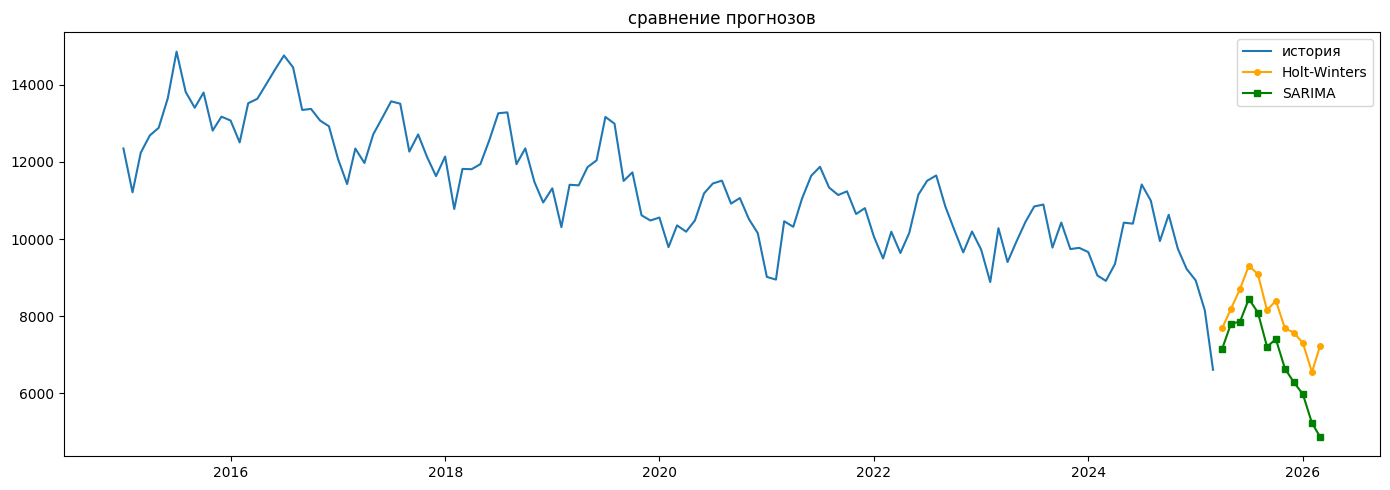

  month  holt_winters  sarima
2025-04          7684    7151
2025-05          8189    7802
2025-06          8704    7859
2025-07          9311    8448
2025-08          9085    8093
2025-09          8153    7207
2025-10          8401    7405
2025-11          7685    6643
2025-12          7575    6289
2026-01          7308    5981
2026-02          6549    5233
2026-03          7237    4869


In [ ]:
sarima_forecast = sarima_model.predict(n_periods=12)

future_dates = pd.date_range(start='2025-04-01', periods=12, freq='MS')

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='история')
plt.plot(future_dates, forecast.values, label='Holt-Winters', color='orange', marker='o', markersize=4)
plt.plot(future_dates, sarima_forecast, label='SARIMA', color='green', marker='s', markersize=4)
plt.title('сравнение прогнозов')
plt.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'month': future_dates.strftime('%Y-%m'),
    'holt_winters': forecast.values.round(0).astype(int),
    'sarima': sarima_forecast.round(0).astype(int)
})
print(comparison.to_string(index=False))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

hw_fitted = fit.fittedvalues
sarima_fitted = sarima_model.predict_in_sample()

print('Holt-Winters:')
print(f'  MAE  = {mean_absolute_error(train, hw_fitted):.0f}')
print(f'  MAPE = {mean_absolute_percentage_error(train, hw_fitted)*100:.2f}%')

print('SARIMA:')
print(f'  MAE  = {mean_absolute_error(train, sarima_fitted):.0f}')
print(f'  MAPE = {mean_absolute_percentage_error(train, sarima_fitted)*100:.2f}%')

Holt-Winters:
  MAE  = 289
  MAPE = 2.71%
SARIMA:
  MAE  = 478
  MAPE = 4.23%


In [ ]:
train_cv = df[df['date'] < '2024-01-01'].set_index('date')['target']
test_cv = df[df['date'] >= '2024-01-01'].set_index('date')['target']

hw_cv = ExponentialSmoothing(
    train_cv, trend='add', seasonal='add', seasonal_periods=12
).fit()

sarima_cv = auto_arima(
    train_cv, seasonal=True, m=12, trend='t', stepwise=True
)

hw_pred = hw_cv.forecast(len(test_cv))
sarima_pred = sarima_cv.predict(n_periods=len(test_cv))

print(f'out-of-sample (2024):')
print(f'  HW    MAE={mean_absolute_error(test_cv, hw_pred):.0f}, MAPE={mean_absolute_percentage_error(test_cv, hw_pred)*100:.2f}%')
print(f'  SARIMA MAE={mean_absolute_error(test_cv, sarima_pred):.0f}, MAPE={mean_absolute_percentage_error(test_cv, sarima_pred)*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


out-of-sample (2024):
  HW    MAE=444, MAPE=5.45%
  SARIMA MAE=462, MAPE=5.54%


посмотрю, что будет, если убрать три месяца 2025

In [ ]:
df2 = dataset[dataset['year'] < 2025].copy()
df2['c1'] = df2['c1'].interpolate(method='linear').bfill()
df2['date'] = pd.to_datetime(df2[['year', 'month']].assign(day=1))

train2 = df2.set_index('date')['target']
print(train2.shape)
print(train2.tail(3))

(120,)
date
2024-10-01    10629
2024-11-01     9751
2024-12-01     9225
Name: target, dtype: int64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


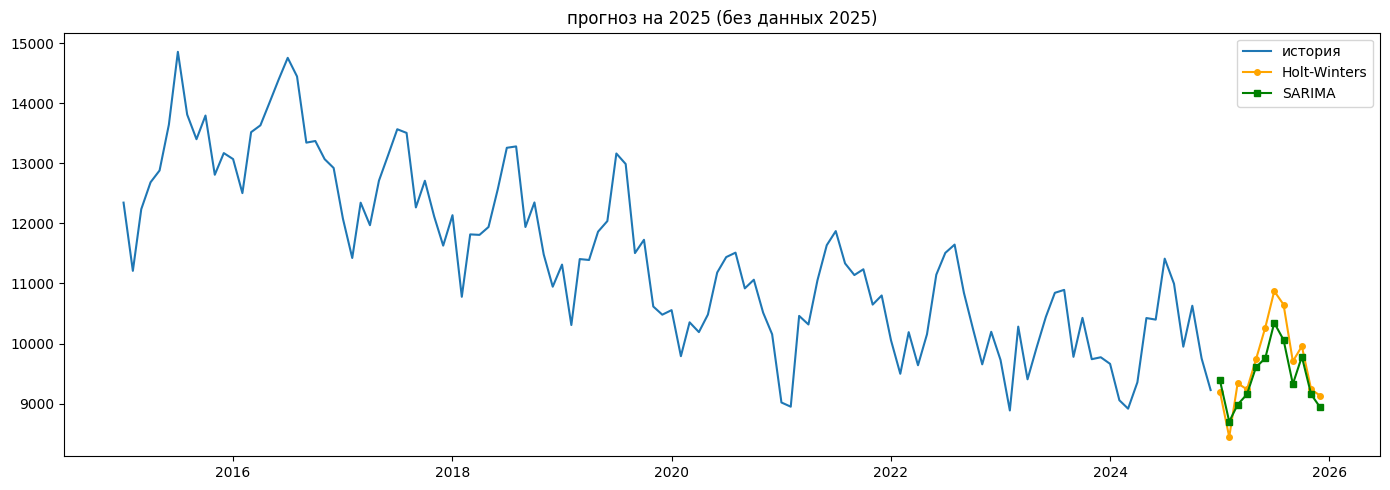

  month  holt_winters  sarima
2025-01          9198    9387
2025-02          8443    8698
2025-03          9337    8983
2025-04          9237    9153
2025-05          9734    9604
2025-06         10263    9755
2025-07         10873   10344
2025-08         10648   10060
2025-09          9702    9325
2025-10          9955    9781
2025-11          9236    9152
2025-12          9131    8936

HW alpha=0.465, beta=0.000, gamma=0.000
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(4, 1, 0)x(2, 0, 0, 12)   Log Likelihood                -899.303
Date:                            Wed, 17 Jun 2026   AIC                           1814.607
Time:                                    17:40:53   BIC                           1836.840
Sample:                                01-01-2015   HQIC                          1823.635
                       

In [ ]:
hw2 = ExponentialSmoothing(
    train2, trend='add', seasonal='add', seasonal_periods=12
).fit()

sarima2 = auto_arima(
    train2, seasonal=True, m=12, trend='t', stepwise=True
)

hw_fc2 = hw2.forecast(12)
sarima_fc2 = sarima2.predict(n_periods=12)

future2 = pd.date_range(start='2025-01-01', periods=12, freq='MS')

plt.figure(figsize=(14, 5))
plt.plot(train2.index, train2, label='история')
plt.plot(future2, hw_fc2.values, label='Holt-Winters', color='orange', marker='o', markersize=4)
plt.plot(future2, sarima_fc2, label='SARIMA', color='green', marker='s', markersize=4)
plt.title('прогноз на 2025 (без данных 2025)')
plt.legend()
plt.tight_layout()
plt.show()

comparison2 = pd.DataFrame({
    'month': future2.strftime('%Y-%m'),
    'holt_winters': hw_fc2.values.round(0).astype(int),
    'sarima': sarima_fc2.round(0).astype(int)
})
print(comparison2.to_string(index=False))
print(f'\nHW alpha={hw2.params["smoothing_level"]:.3f}, beta={hw2.params["smoothing_trend"]:.3f}, gamma={hw2.params["smoothing_seasonal"]:.3f}')
print(sarima2.summary())

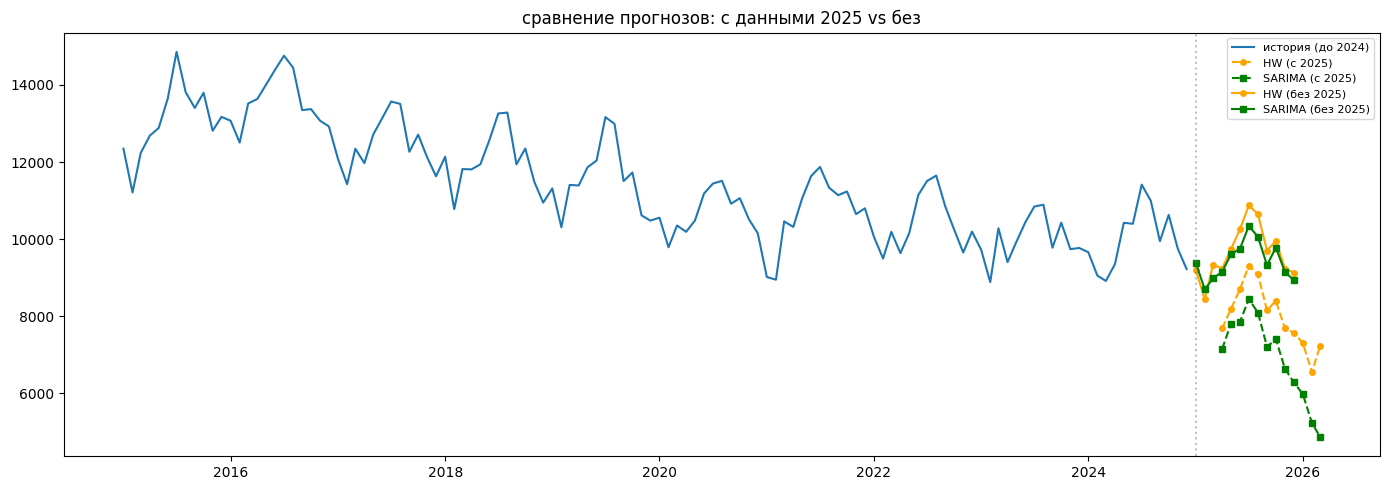

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train2.index, train2, label='история (до 2024)')

plt.plot(future_dates, forecast.values, label='HW (с 2025)', color='orange', linestyle='--', marker='o', markersize=4)
plt.plot(future_dates, sarima_forecast, label='SARIMA (с 2025)', color='green', linestyle='--', marker='s', markersize=4)

plt.plot(future2, hw_fc2.values, label='HW (без 2025)', color='orange', marker='o', markersize=4)
plt.plot(future2, sarima_fc2, label='SARIMA (без 2025)', color='green', marker='s', markersize=4)

plt.axvline(x=pd.Timestamp('2025-01-01'), color='gray', linestyle=':', alpha=0.5)
plt.title('сравнение прогнозов: с данными 2025 vs без')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

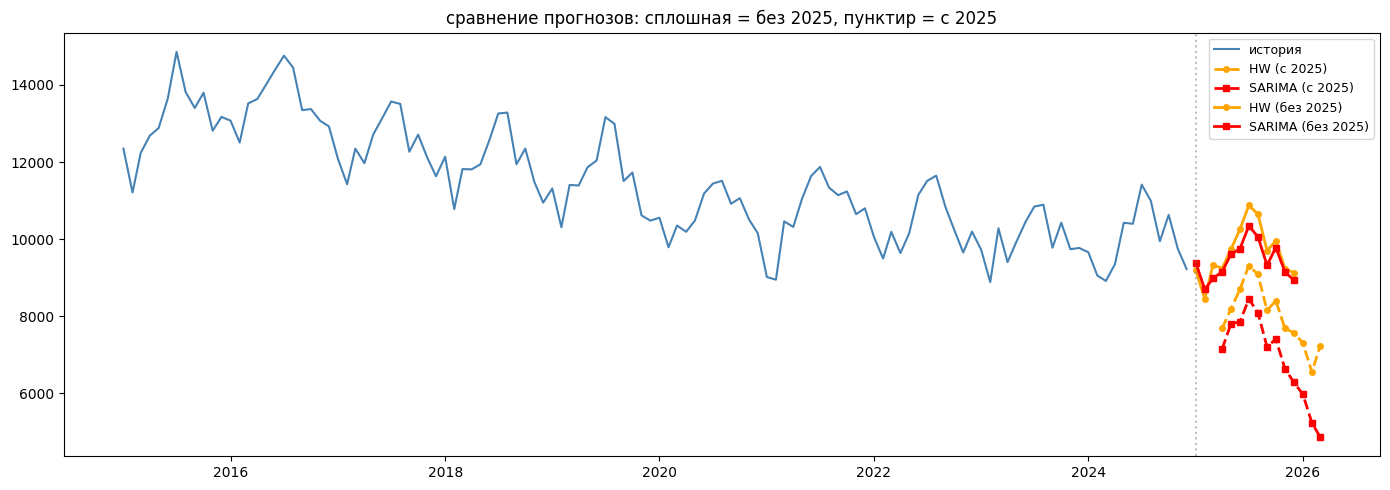

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train2.index, train2, label='история', color='steelblue')

plt.plot(future_dates, forecast.values, label='HW (с 2025)', color='orange', linestyle='--', marker='o', markersize=4, linewidth=2)
plt.plot(future_dates, sarima_forecast, label='SARIMA (с 2025)', color='red', linestyle='--', marker='s', markersize=4, linewidth=2)

plt.plot(future2, hw_fc2.values, label='HW (без 2025)', color='orange', linestyle='-', marker='o', markersize=4, linewidth=2)
plt.plot(future2, sarima_fc2, label='SARIMA (без 2025)', color='red', linestyle='-', marker='s', markersize=4, linewidth=2)

plt.axvline(x=pd.Timestamp('2025-01-01'), color='gray', linestyle=':', alpha=0.5)
plt.title('сравнение прогнозов: сплошная = без 2025, пунктир = с 2025')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

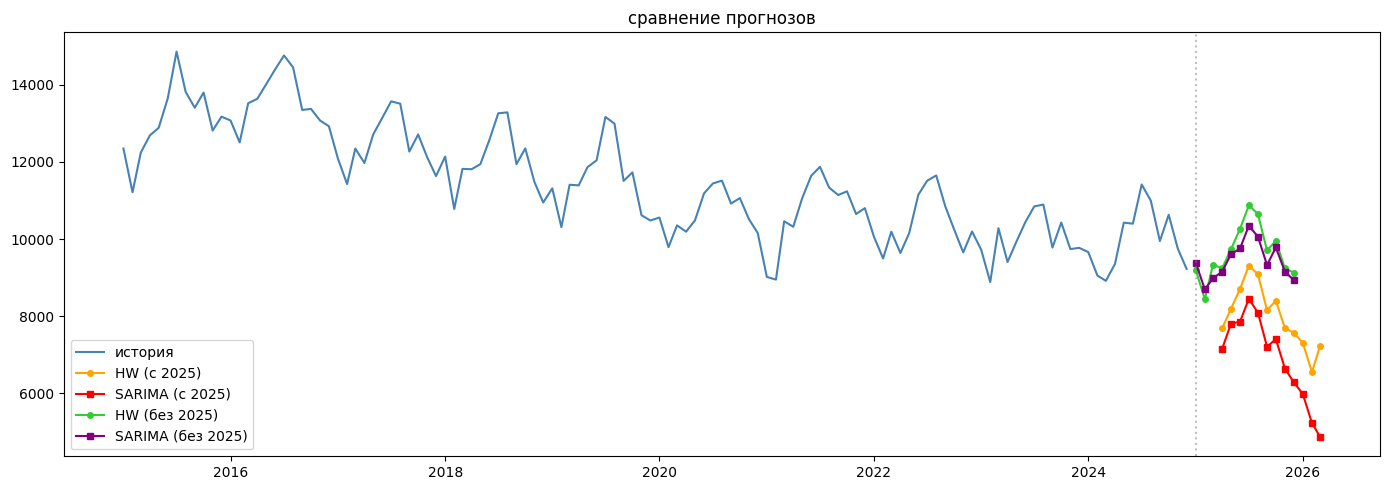

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train2.index, train2, label='история', color='steelblue')

plt.plot(future_dates, forecast.values, label='HW (с 2025)', color='orange', marker='o', markersize=4)
plt.plot(future_dates, sarima_forecast, label='SARIMA (с 2025)', color='red', marker='s', markersize=4)

plt.plot(future2, hw_fc2.values, label='HW (без 2025)', color='limegreen', marker='o', markersize=4)
plt.plot(future2, sarima_fc2, label='SARIMA (без 2025)', color='purple', marker='s', markersize=4)

plt.axvline(x=pd.Timestamp('2025-01-01'), color='gray', linestyle=':', alpha=0.5)
plt.title('сравнение прогнозов')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
train_cv2 = df2[df2['date'] < '2024-01-01'].set_index('date')['target']
test_cv2 = df2[df2['date'] >= '2024-01-01'].set_index('date')['target']

hw_cv2 = ExponentialSmoothing(
    train_cv2, trend='add', seasonal='add', seasonal_periods=12
).fit()

sarima_cv2 = auto_arima(
    train_cv2, seasonal=True, m=12, trend='t', stepwise=True
)

hw_pred2 = hw_cv2.forecast(len(test_cv2))
sarima_pred2 = sarima_cv2.predict(n_periods=len(test_cv2))

print('out-of-sample (2024):')
print(f'  HW     MAE={mean_absolute_error(test_cv2, hw_pred2):.0f}, MAPE={mean_absolute_percentage_error(test_cv2, hw_pred2)*100:.2f}%')
print(f'  SARIMA MAE={mean_absolute_error(test_cv2, sarima_pred2):.0f}, MAPE={mean_absolute_percentage_error(test_cv2, sarima_pred2)*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


out-of-sample (2024):
  HW     MAE=305, MAPE=3.10%
  SARIMA MAE=341, MAPE=3.40%


что если убрать только крайний месяц, он как будто бы не завершился на момент сбора данных, занчение меньше предполагаемого в марте 2025

In [ ]:
df3 = dataset[(dataset['year'] < 2025) | ((dataset['year'] == 2025) & (dataset['month'] <= 2))].copy()
df3['c1'] = df3['c1'].interpolate(method='linear').bfill()
df3['date'] = pd.to_datetime(df3[['year', 'month']].assign(day=1))

train3 = df3.set_index('date')['target']
print(train3.shape)
print(train3.tail(3))

(122,)
date
2024-12-01    9225
2025-01-01    8927
2025-02-01    8152
Name: target, dtype: int64


In [ ]:
hw3 = ExponentialSmoothing(
    train3, trend='add', seasonal='add', seasonal_periods=12
).fit()

sarima3 = auto_arima(
    train3, seasonal=True, m=12, trend='t', stepwise=True
)

hw_fc3 = hw3.forecast(12)
sarima_fc3 = sarima3.predict(n_periods=12)
future3 = pd.date_range(start='2025-03-01', periods=12, freq='MS')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
comparison3 = pd.DataFrame({
    'month': future3.strftime('%Y-%m'),
    'holt_winters': hw_fc3.values.round(0).astype(int),
    'sarima': sarima_fc3.round(0).astype(int)
})
print(comparison3.to_string(index=False))

  month  holt_winters  sarima
2025-03          9147    8913
2025-04          9034    8856
2025-05          9539    9319
2025-06         10055    9727
2025-07         10662   10260
2025-08         10436   10008
2025-09          9503    9106
2025-10          9750    9334
2025-11          9035    8620
2025-12          8925    8460
2026-01          8659    8239
2026-02          7901    7527


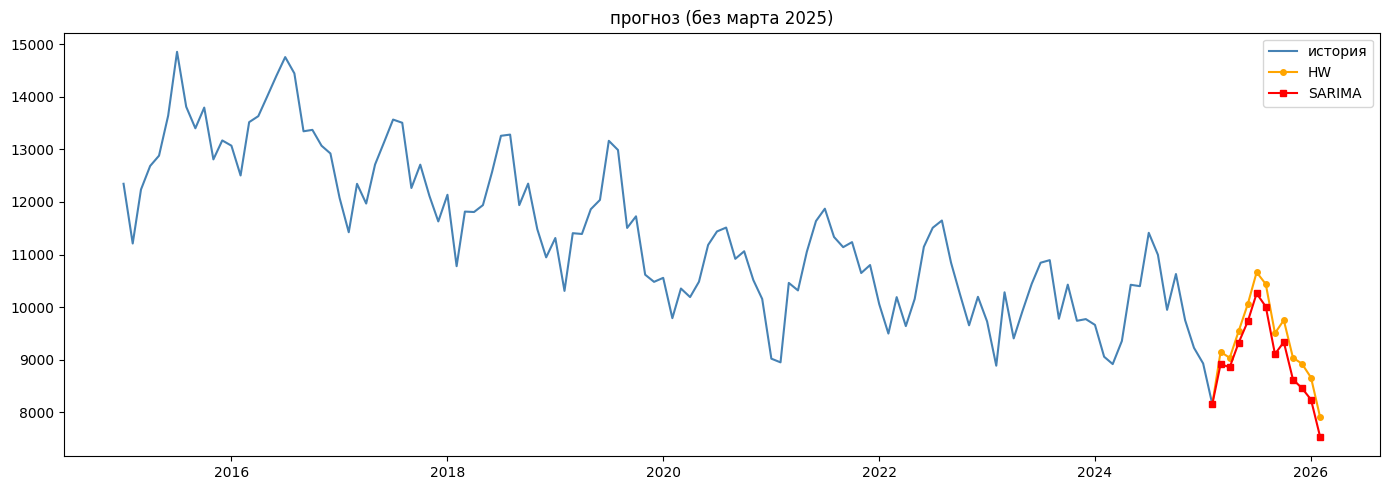

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train3.index, train3, label='история', color='steelblue')

last_point = train3.iloc[[-1]]
plt.plot(last_point.index.append(future3),
         pd.concat([last_point, pd.Series(hw_fc3.values, index=future3)]),
         label='HW', color='orange', marker='o', markersize=4)
plt.plot(last_point.index.append(future3),
         pd.concat([last_point, pd.Series(sarima_fc3, index=future3)]),
         label='SARIMA', color='red', marker='s', markersize=4)

plt.title('прогноз (без марта 2025)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
train_cv3 = df3[df3['date'] < '2024-01-01'].set_index('date')['target']
test_cv3 = df3[df3['date'] >= '2024-01-01'].set_index('date')['target']

hw_cv3 = ExponentialSmoothing(
    train_cv3, trend='add', seasonal='add', seasonal_periods=12
).fit()

sarima_cv3 = auto_arima(
    train_cv3, seasonal=True, m=12, trend='t', stepwise=True
)

hw_pred3 = hw_cv3.forecast(len(test_cv3))
sarima_pred3 = sarima_cv3.predict(n_periods=len(test_cv3))

print(f'out-of-sample ({len(test_cv3)} месяцев, 2024-01 по 2025-02):')
print(f'  HW     MAE={mean_absolute_error(test_cv3, hw_pred3):.0f}, MAPE={mean_absolute_percentage_error(test_cv3, hw_pred3)*100:.2f}%')
print(f'  SARIMA MAE={mean_absolute_error(test_cv3, sarima_pred3):.0f}, MAPE={mean_absolute_percentage_error(test_cv3, sarima_pred3)*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


out-of-sample (14 месяцев, 2024-01 по 2025-02):
  HW     MAE=282, MAPE=2.90%
  SARIMA MAE=309, MAPE=3.11%


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'вариант': ['с 2025 (3 мес)', 'без 2025', 'без марта 2025'],
    'HW MAE': [444, 305, 282],
    'HW MAPE': ['5.45%', '3.10%', '2.90%'],
    'SARIMA MAE': [462, 341, 309],
    'SARIMA MAPE': ['5.54%', '3.40%', '3.11%']
})

display(results)

,вариант,HW MAE,HW MAPE,SARIMA MAE,SARIMA MAPE
0,с 2025 (3 мес),444,5.45%,462,5.54%
1,без 2025,305,3.10%,341,3.40%
2,без марта 2025,282,2.90%,309,3.11%


Включение января и февраля 2025 дало модели дополнительную информацию о продолжении тренда, а исключение аномального марта убрало шум. Holt-Winters стабильно точнее SARIMA во всех вариантах.
Итого финальное решение по 2.1: Holt-Winters, обучение на 122 точках (январь 2015 — февраль 2025, без марта), MAPE = 2.90%

In [ ]:
final_forecast = pd.DataFrame({
    'Месяц': future3.strftime('%Y-%m'),
    'Прогноз (Holt-Winters)': hw_fc3.values.round(0).astype(int)
})

display(final_forecast)

,Месяц,Прогноз (Holt-Winters)
0,2025-03,9147
1,2025-04,9034
2,2025-05,9539
3,2025-06,10055
4,2025-07,10662
5,2025-08,10436
6,2025-09,9503
7,2025-10,9750
8,2025-11,9035
9,2025-12,8925
